Attempting to mount Google Drive...
Mounted at /content/drive
Google Drive mounted.
Gráfico de Pareto guardado en: /content/drive/MyDrive/PROYECTO DE GRADO/pareto_fibras_abc.png


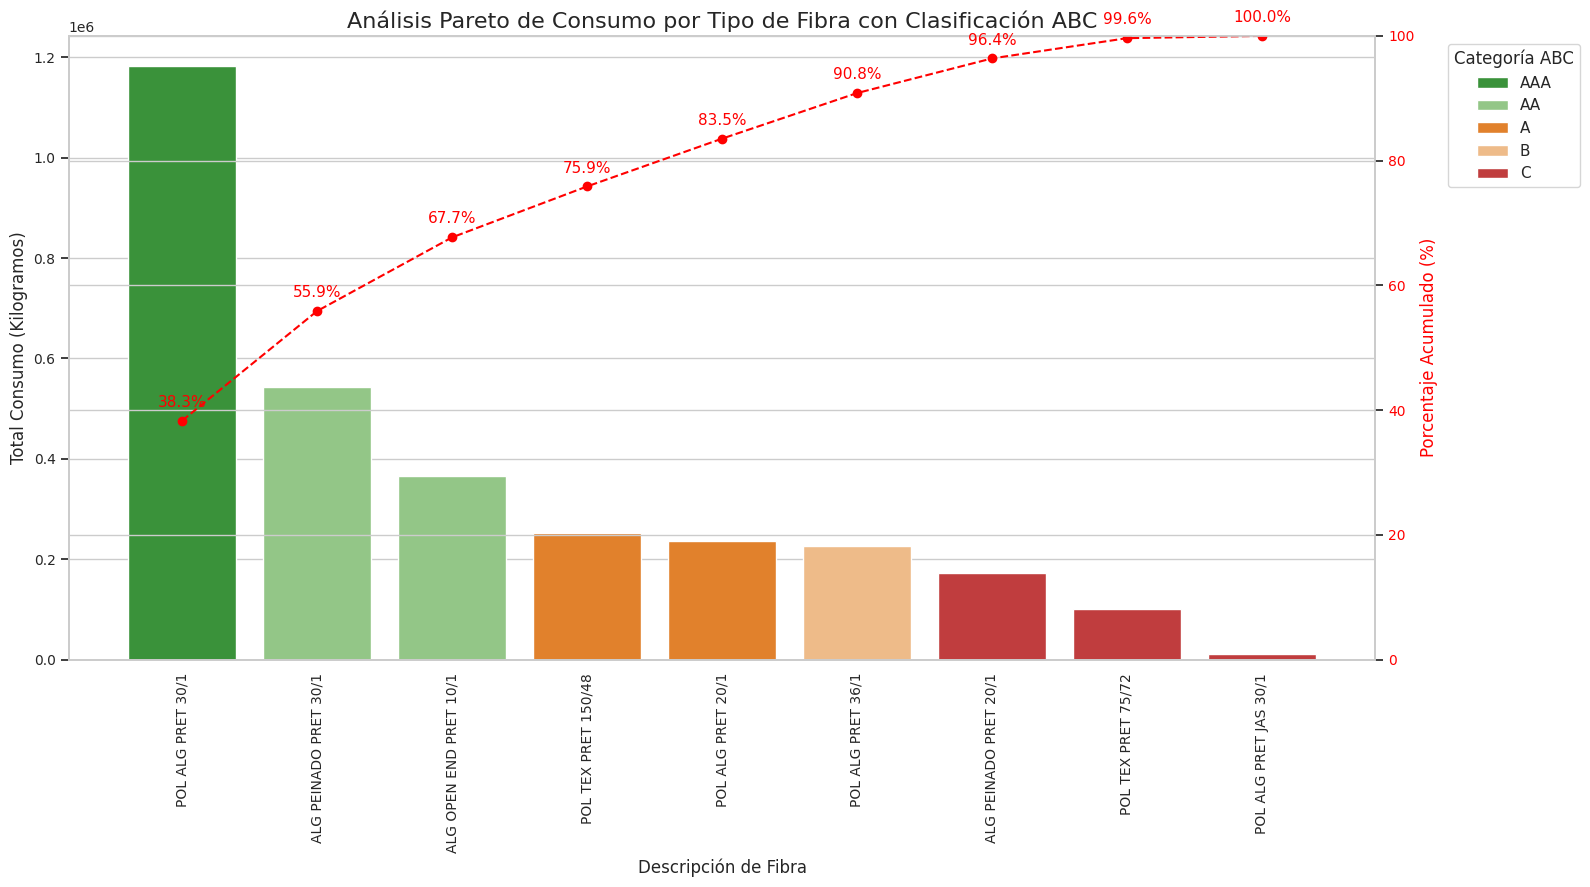

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive # Import drive for mounting
import os # Import os for path checking

# Configure plot style for consistency
sns.set_style("whitegrid")

# Ensure Google Drive is mounted
print("Attempting to mount Google Drive...")
drive.mount('/content/drive', force_remount=True)
print("Google Drive mounted.")

# Load the generated data file from Google Drive
file_path = '/content/drive/MyDrive/PROYECTO DE GRADO/MDT_CADENA_SUMINISTRO_TEXTIL.csv'

# Add a check to confirm file existence before attempting to read
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found after mounting Google Drive.")
    raise FileNotFoundError(f"File not found: {file_path}. Please check your Google Drive path and ensure the file exists.")

df_ml = pd.read_csv(file_path)

# Define the 36 months of consumption data
meses_36 = [
    "consumo Junio 2023", "consumo Julio 2023", "consumo Agosto 2023", "consumo Septiembre 2023",
    "consumo Octubre 2023", "consumo Noviembre 2023", "consumo Diciembre 2023", "consumo Enero 2024",
    "consumo Febrero 2024", "consumo Marzo 2024", "consumo Abril 2024", "consumo Mayo 2024",
    "consumo Junio 2024", "consumo Julio 2024", "consumo Agosto 2024", "consumo Septiembre 2024",
    "consumo Octubre 2024", "consumo Noviembre 2024", "consumo Diciembre 2024", "consumo Enero 2025",
    "consumo Febrero 2025", "consumo Marzo 2025", "consumo Abril 2025", "consumo Mayo 2025",
    "consumo Junio 2025", "consumo Julio 2025", "consumo Agosto 2025", "consumo Septiembre 2025",
    "consumo Octubre 2025", "consumo Noviembre 2025", "consumo Diciembre 2025", "consumo Enero 2026",
    "consumo Febrero 2026", "consumo Marzo 2026", "consumo Abril 2026", "consumo Mayo 2026"
]

# Calculate total consumption for each SKU (fiber + color combination)
df_ml['Total_Consumo_SKU'] = df_ml[meses_36].sum(axis=1)

# Group by 'Descripcion fibra' to get total consumption per fiber type
df_fibra_consumption = df_ml.groupby('Descripcion fibra')['Total_Consumo_SKU'].sum().reset_index()

# Sort fibers by total consumption in descending order
df_fibra_consumption = df_fibra_consumption.sort_values(by='Total_Consumo_SKU', ascending=False).reset_index(drop=True)

# Calculate cumulative sum and cumulative percentage for Pareto analysis
df_fibra_consumption['Cumulative_Consumo'] = df_fibra_consumption['Total_Consumo_SKU'].cumsum()
df_fibra_consumption['Cumulative_Percentage'] = (df_fibra_consumption['Cumulative_Consumo'] / df_fibra_consumption['Total_Consumo_SKU'].sum()) * 100

# Function to assign custom ABC categories based on cumulative percentage
def assign_custom_abc_category(percentage):
    if percentage <= 50:  # Top contributors
        return 'AAA'
    elif percentage <= 70: # Next tier
        return 'AA'
    elif percentage <= 85: # Standard 'A' tier
        return 'A'
    elif percentage <= 95: # 'B' tier
        return 'B'
    else:                 # Least contributors
        return 'C'

df_fibra_consumption['ABC_Category'] = df_fibra_consumption['Cumulative_Percentage'].apply(assign_custom_abc_category)

# Define a specific color palette for ABC categories for clear visualization
category_colors = {'AAA': '#2ca02c', 'AA': '#8cd17c', 'A': '#ff7f0e', 'B': '#ffbb78', 'C': '#d62728'}

# Create the Pareto chart
fig, ax1 = plt.subplots(figsize=(16, 9))

# Bar plot for individual fiber consumption, colored by assigned ABC Category
sns.barplot(
    x='Descripcion fibra',
    y='Total_Consumo_SKU',
    hue='ABC_Category',
    data=df_fibra_consumption,
    ax=ax1,
    dodge=False, # Important for correct coloring with single bars
    palette=category_colors,
    hue_order=['AAA', 'AA', 'A', 'B', 'C'] # Ensure a consistent order in legend
)

ax1.set_xlabel('Descripción de Fibra', fontsize=12)
ax1.set_ylabel('Total Consumo (Kilogramos)', fontsize=12)
ax1.tick_params(axis='x', rotation=90)
ax1.set_title('Análisis Pareto de Consumo por Tipo de Fibra con Clasificación ABC', fontsize=16)
ax1.legend(title='Categoría ABC', bbox_to_anchor=(1.05, 1), loc='upper left')

# Create a second y-axis for the cumulative percentage line plot
ax2 = ax1.twinx()
ax2.plot(
    ax1.get_xticks(),
    df_fibra_consumption['Cumulative_Percentage'],
    color='red',
    marker='o',
    linestyle='--'
)
ax2.set_ylabel('Porcentaje Acumulado (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100) # Ensure cumulative percentage scale from 0 to 100

# Add annotations for cumulative percentage at each point on the line
for i, percentage in enumerate(df_fibra_consumption['Cumulative_Percentage']):
    ax2.annotate(
        f'{percentage:.1f}%',
        (i, percentage),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        color='red'
    )

plt.tight_layout() # Adjust layout to prevent labels/elements from overlapping

# Save the plot to Google Drive
output_plot_path = '/content/drive/MyDrive/PROYECTO DE GRADO/pareto_fibras_abc.png'
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"Gráfico de Pareto guardado en: {output_plot_path}")

plt.show()

In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# 1. Cargar y filtrar
ruta = '/content/drive/MyDrive/PROYECTO DE GRADO/MDT_FIBRA.csv'
df = pd.read_csv(ruta, delimiter=';')
df_fibra = df[df['Descripcion fibra'] == 'POL ALG PRET 30/1'].copy()

# 2. Convertir a formato largo (serie de tiempo)
# Obtenemos solo las columnas de consumo
cols_consumo = [c for c in df_fibra.columns if 'consumo' in c]
serie = df_fibra[cols_consumo].values.flatten()

# 3. Crear dataset de aprendizaje (Mes actual vs Mes anterior)
# Esto crea una relación: X = mes anterior, y = mes actual
data = pd.DataFrame({'Mes_Actual': serie[1:], 'Mes_Anterior': serie[:-1]})

X = data[['Mes_Anterior']]
y = data['Mes_Actual']

# 4. Dividir y Entrenar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Ridge()
model.fit(X_train, y_train)

# 5. Evaluación
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)

print(f"Resultados para POL ALG PRET 30/1:")
print(f"Error Absoluto Medio (MAE): {mae:.2f} KG")
print(f"Esto significa que el modelo se equivoca en promedio {mae:.2f} kg por mes.")

Resultados para POL ALG PRET 30/1:
Error Absoluto Medio (MAE): 116135.10 KG
Esto significa que el modelo se equivoca en promedio 116135.10 kg por mes.


In [13]:
from sklearn.ensemble import RandomForestRegressor

# Crear más "memoria" para el modelo
data = pd.DataFrame({
    'T': serie[3:],             # Mes actual
    'T_1': serie[2:-1],         # Mes anterior
    'T_2': serie[1:-2],         # Hace 2 meses
    'T_3': serie[:-3]           # Hace 3 meses
})

X = data[['T_1', 'T_2', 'T_3']] # El modelo ahora analiza la tendencia de 3 meses
y = data['T']

# Usamos Random Forest que es mejor capturando patrones no lineales
model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. Cargar Datos
ruta = '/content/drive/MyDrive/PROYECTO DE GRADO/MDT_FIBRA.csv'
df = pd.read_csv(ruta, delimiter=';')

# Filtrar para la fibra principal (POL ALG PRET 30/1) como acordamos
df_fibra = df[df['Descripcion fibra'] == 'POL ALG PRET 30/1'].copy()

# 2. Ingeniería de Características (Crear memoria/Lags para evitar series planas)
# Transformamos la serie de consumos en un formato supervisado
cols_consumo = [c for c in df_fibra.columns if 'consumo' in c]
serie = df_fibra[cols_consumo].values.flatten()

data = pd.DataFrame({
    'T': serie[3:],             # Target (Mes actual)
    'T_1': serie[2:-1],         # Mes anterior (Lag 1)
    'T_2': serie[1:-2],         # Mes anterior (Lag 2)
    'T_3': serie[:-3]           # Mes anterior (Lag 3)
})

X = data[['T_1', 'T_2', 'T_3']]
y = data['T']

# 3. División Rigurosa (Train/Test)
# Es vital no mezclar el futuro en el entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 4. Preprocesamiento (Escalado correcto: Ajustar solo en Train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Modelación (Comparativa contra Línea Base)
modelos = {
    "Linea Base (Promedio)": DummyRegressor(strategy="mean"),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1)
}

resultados = []

for nombre, model in modelos.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    resultados.append({'Modelo': nombre, 'MAE': mae, 'R2': r2})

# 6. Tabla Comparativa (Cumplimiento de Rúbrica)
df_res = pd.DataFrame(resultados)
print("Tabla Comparativa de Modelos (vs Línea Base):")
print(df_res)

Tabla Comparativa de Modelos (vs Línea Base):
                  Modelo            MAE        R2
0  Linea Base (Promedio)  105058.670330 -0.162005
1       Ridge Regression   93424.908376  0.049942
2          Random Forest   88486.841429  0.116371
3                XGBoost   65817.570312  0.536770


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# 1. Cargar y filtrar específicamente por la fibra objetivo
ruta = '/content/drive/MyDrive/PROYECTO DE GRADO/MDT_FIBRA.csv'
df = pd.read_csv(ruta, delimiter=';')

fibra_objetivo = 'POL ALG PRET 30/1'
df_fibra = df[df['Descripcion fibra'] == fibra_objetivo].copy()

# Verificar si hay suficientes datos para la fibra seleccionada
if df_fibra.empty:
    print(f"Error: La fibra '{fibra_objetivo}' no fue encontrada o no tiene datos suficientes.")
    raise ValueError("Fibra no encontrada o sin datos.")

# 2. Ingeniería de Características (Crear memoria/Lags para evitar series planas)
# Transformamos la serie de consumos en un formato supervisado
# Obtenemos todas las columnas de consumo para esta fibra
cols_consumo_all = [c for c in df_fibra.columns if 'consumo' in c]
# Aplanar la fila de consumos en una serie de tiempo
serie = df_fibra[cols_consumo_all].values.flatten()

# Crear el dataset de lags
# Aseguramos que haya suficientes datos para crear los lags (al menos 4 puntos para T, T-1, T-2, T-3)
if len(serie) < 4:
    print(f"Error: La fibra '{fibra_objetivo}' tiene solo {len(serie)} puntos de consumo. Se necesitan al menos 4 para crear lags.")
    raise ValueError("Datos insuficientes para crear lags.")

data = pd.DataFrame({
    'T': serie[3:],             # Target (Mes actual)
    'T_1': serie[2:-1],         # Mes anterior (Lag 1)
    'T_2': serie[1:-2],         # Mes anterior (Lag 2)
    'T_3': serie[:-3]           # Mes anterior (Lag 3)
})

X = data[['T_1', 'T_2', 'T_3']]
y = data['T']

# 3. División Train/Test (Crucial para no tener fuga de datos - Criterio 2)
# Usamos shuffle=False para mantener el orden temporal en series de tiempo
# Aseguramos que hay suficientes muestras después de crear los lags
if len(X) < 2:
    print(f"Error: Después de crear lags, solo quedan {len(X)} muestras. Se necesitan al menos 2 para una división train/test.")
    raise ValueError("Datos insuficientes para split.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 4. Preprocesamiento (Escalado solo en Train para evitar fugas - Criterio 3)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Evaluación de modelos
modelos = {
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor()
}

resultados = []

for nombre, model in modelos.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    # Métricas requeridas: MAE, RMSE y R2
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    resultados.append({'Algoritmo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

# 6. Mostrar resultados organizados
df_res = pd.DataFrame(resultados)
print("=== EVALUACIÓN ESPECIALIZADA PARA FIBRA:", fibra_objetivo, "===")
print(df_res)

=== EVALUACIÓN ESPECIALIZADA PARA FIBRA: POL ALG PRET 30/1 ===
          Algoritmo           MAE           RMSE        R2
0  Ridge Regression  93424.908376  109673.165969  0.049942
1     Random Forest  88486.841429  105769.479395  0.116371
2           XGBoost  71230.859375   80760.820600  0.484830


## Tabla de Resultados Comparativos del Modelo

In [16]:
# Mostrar la tabla de resultados
display(df_res)

# Guardar la tabla en Google Drive como archivo Excel
output_results_path = '/content/drive/MyDrive/PROYECTO DE GRADO/Resultados_Modelos_POL_ALG_PRET_30_1.xlsx'
df_res.to_excel(output_results_path, index=False)
print(f"Tabla de resultados guardada en: {output_results_path}")

,Algoritmo,MAE,RMSE,R2
0,Ridge Regression,93424.908376,109673.165969,0.049942
1,Random Forest,88486.841429,105769.479395,0.116371
2,XGBoost,71230.859375,80760.820600,0.484830


Tabla de resultados guardada en: /content/drive/MyDrive/PROYECTO DE GRADO/Resultados_Modelos_POL_ALG_PRET_30_1.xlsx


[PROCESO] Conectando con Google Drive...
Mounted at /content/drive
[PROCESO] Leyendo archivo desde la ruta: /content/drive/MyDrive/PROYECTO DE GRADO/MDT_CADENA_SUMINISTRO_TEXTIL.csv

[AUDITORÍA] Dataset original: 144 SKUs totales.
[AUDITORÍA] Dataset filtrado Clase A: 30 SKUs críticos identificados.
[ÉXITO] Matriz de Datos Tabular (MDT) exportada correctamente en: /content/drive/MyDrive/PROYECTO DE GRADO/MDT_SOLO_A.csv

[PROCESO] Generando Análisis Exploratorio Univariado...


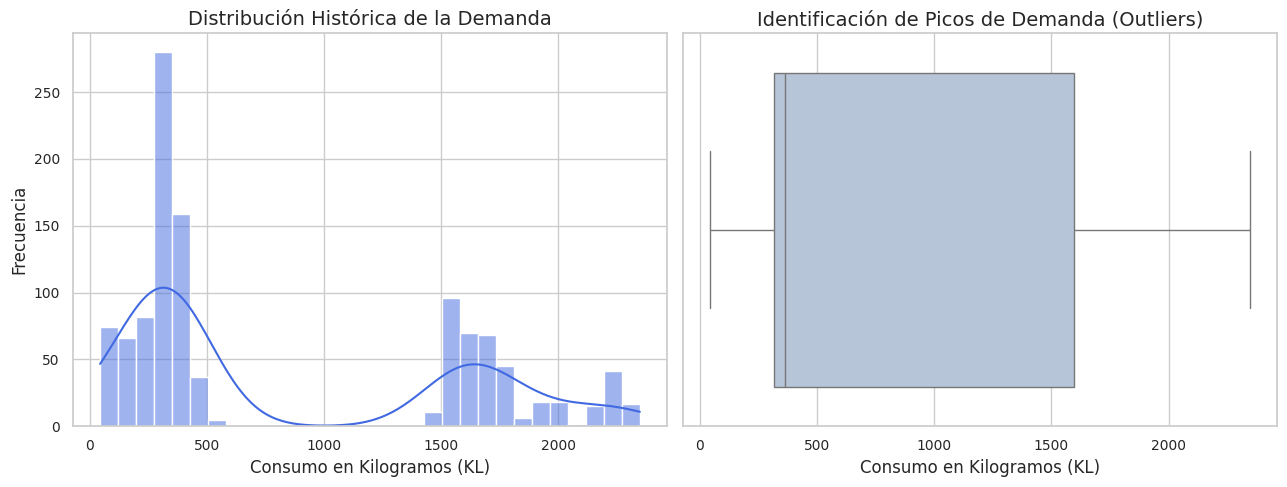

 -> Media de la demanda: 839.76 KL
 -> Desviación Estándar: 730.93 KL
 -> Coeficiente de Sesgo (Skewness): 0.65
 -> Coeficiente de Curtosis: -1.29

[PROCESO] Generando Análisis Exploratorio Bivariado...


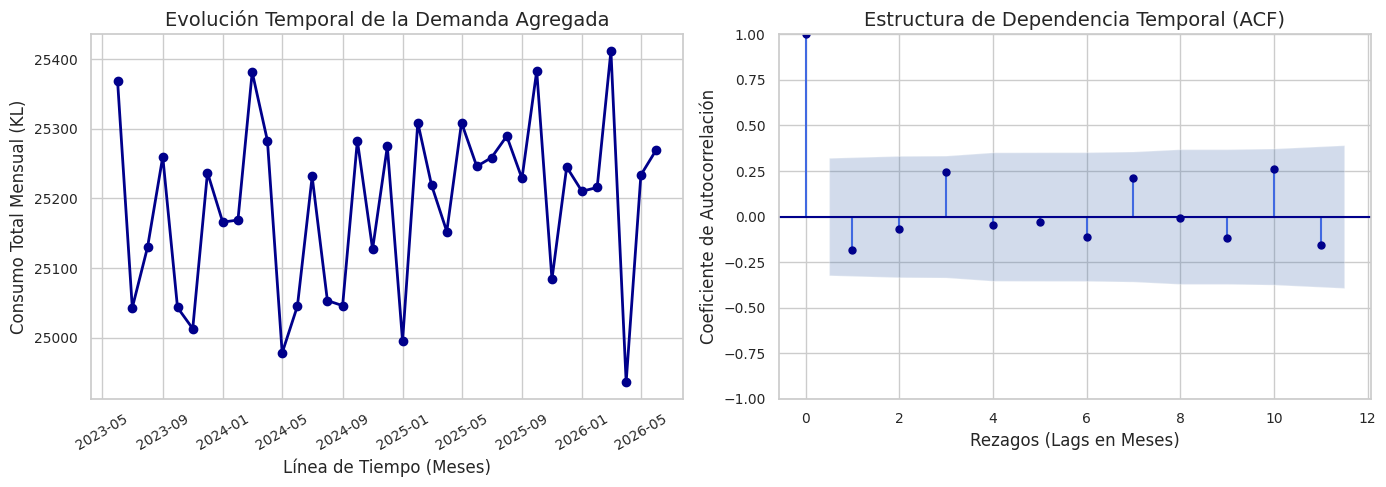

[PROCESO] Generando Análisis Exploratorio Multivariado por Familias de Fibras...


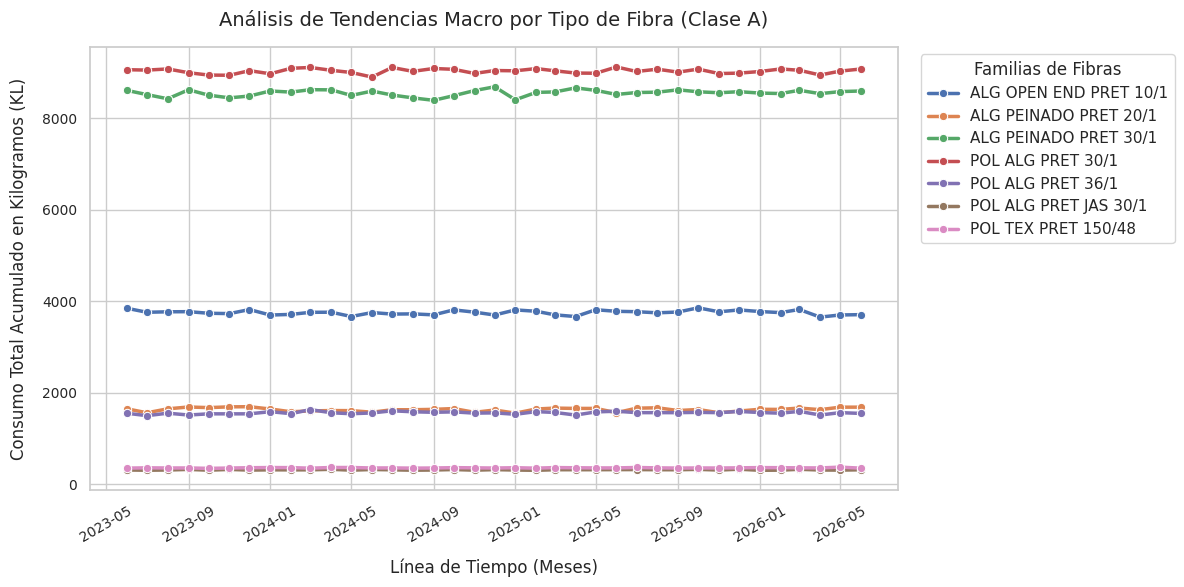


[INFO] ¡Ejecución del EDA Finalizada! Los archivos gráficos macro y la MDT fueron actualizados en tu Drive.


In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from google.colab import drive

# Configuración estética de los gráficos para reportes científicos (IEEE)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# ==============================================================================
# FASE 1: CONEXIÓN A DRIVE Y CONSTRUCCIÓN DE LA MDT (SÓLO PRODUCTOS CLASE A)
# ==============================================================================
print("[PROCESO] Conectando con Google Drive...")
drive.mount('/content/drive', force_remount=True)

# Ruta exacta especificada
file_path = '/content/drive/MyDrive/PROYECTO DE GRADO/MDT_CADENA_SUMINISTRO_TEXTIL.csv'

print(f"[PROCESO] Leyendo archivo desde la ruta: {file_path}")
try:
    df_raw = pd.read_csv(file_path, sep=',', encoding='utf-8')
except Exception:
    df_raw = pd.read_csv(file_path, sep=',', encoding='latin-1')

# Limpieza profunda de nombres de columnas y eliminación de nulos estructurales
df_raw.columns = df_raw.columns.str.strip()
df_raw['Clasificacion ABC'] = df_raw['Clasificacion ABC'].astype(str).str.strip().str.upper()
df_raw = df_raw.dropna(subset=['Clasificacion ABC']).copy()

# FILTRO ROBUSTO: Captura cualquier celda que contenga la letra 'A'
df_class_A = df_raw[df_raw['Clasificacion ABC'].str.contains('A', na=False)].copy()

print(f"\n[AUDITORÍA] Dataset original: {df_raw.shape[0]} SKUs totales.")
print(f"[AUDITORÍA] Dataset filtrado Clase A: {df_class_A.shape[0]} SKUs críticos identificados.")

# Control de flujo en caso de que el filtro falle por completo
if df_class_A.shape[0] == 0:
    print("\n[ALERTA] No se detectaron filas con 'A'. Diagnosticando...")
    print(df_raw['Clasificacion ABC'].unique())
    print("Procediendo temporalmente con el dataset completo para no frenar el EDA...")
    df_class_A = df_raw.copy()

# Transformación de formato ancho a largo (Melt)
id_vars = ['Descripcion fibra', 'Descripcion color', 'Estado', 'Clasificacion ABC', 'Inventario', 'Costo de almacenamiento']
value_vars = [col for col in df_class_A.columns if 'consumo' in col.lower()]

df_long = pd.melt(
    df_class_A,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Periodo_Raw',
    value_name='Demanda_KL'
)

# Mapeador cronológico estandarizado
meses_dict = {
    'Junio': '06', 'Julio': '07', 'Agosto': '08', 'Septiembre': '09', 'Octubre': '10', 'Noviembre': '11', 'Diciembre': '12',
    'Enero': '01', 'Febrero': '02', 'Marzo': '03', 'Abril': '04', 'Mayo': '05'
}

def convertir_fecha(texto):
    texto_limpio = texto.lower().replace('consumo ', '').strip()
    partes = texto_limpio.split(' ')
    mes_nombre = partes[0].capitalize()
    anio = partes[1]
    mes_num = meses_dict[mes_nombre]
    return f"{anio}-{mes_num}-01"

df_long['Fecha'] = pd.to_datetime(df_long['Periodo_Raw'].apply(convertir_fecha))

# Limpieza y conversión de la variable Costo de Almacenamiento
df_long['Costo_Almacenamiento'] = (
    df_long['Costo de almacenamiento']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
    .astype(float)
)

# Forzar Demanda a tipo numérico limpiando posibles vacíos
df_long['Demanda_KL'] = pd.to_numeric(df_long['Demanda_KL'], errors='coerce').fillna(0)

# ESTRUCTURACIÓN CORRECTA: Mantenemos fibra y color, y creamos el ID_SKU combinado
df_long['ID_SKU'] = df_long['Descripcion fibra'].astype(str) + " - " + df_long['Descripcion color'].astype(str)

mdt_A = df_long[[
    'Fecha', 'ID_SKU', 'Descripcion fibra', 'Descripcion color',
    'Clasificacion ABC', 'Inventario', 'Costo_Almacenamiento', 'Demanda_KL'
]]

mdt_A = mdt_A.sort_values(by=['ID_SKU', 'Fecha']).reset_index(drop=True)

# Guardar la MDT limpia en Drive
output_mdt_path = '/content/drive/MyDrive/PROYECTO DE GRADO/MDT_SOLO_A.csv'
mdt_A.to_csv(output_mdt_path, sep=';', index=False, encoding='utf-8')
print(f"[ÉXITO] Matriz de Datos Tabular (MDT) exportada correctamente en: {output_mdt_path}\n")


# ==============================================================================
# FASE 2: EJECUCIÓN DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==============================================================================
print("[PROCESO] Generando Análisis Exploratorio Univariado...")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(mdt_A['Demanda_KL'], kde=True, color='royalblue', bins=30, ax=axes[0])
axes[0].set_title('Distribución Histórica de la Demanda')
axes[0].set_xlabel('Consumo en Kilogramos (KL)')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=mdt_A['Demanda_KL'], color='lightsteelblue', ax=axes[1])
axes[1].set_title('Identificación de Picos de Demanda (Outliers)')
axes[1].set_xlabel('Consumo en Kilogramos (KL)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO DE GRADO/eda_univariado.png', dpi=300)
plt.show()

print(f" -> Media de la demanda: {mdt_A['Demanda_KL'].mean():.2f} KL")
print(f" -> Desviación Estándar: {mdt_A['Demanda_KL'].std():.2f} KL")
print(f" -> Coeficiente de Sesgo (Skewness): {mdt_A['Demanda_KL'].skew():.2f}")
print(f" -> Coeficiente de Curtosis: {mdt_A['Demanda_KL'].kurt():.2f}\n")


print("[PROCESO] Generando Análisis Exploratorio Bivariado...")
demanda_macro = mdt_A.groupby('Fecha')['Demanda_KL'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(demanda_macro['Fecha'], demanda_macro['Demanda_KL'], marker='o', color='darkblue', linewidth=2)
axes[0].set_title('Evolución Temporal de la Demanda Agregada')
axes[0].set_xlabel('Línea de Tiempo (Meses)')
axes[0].set_ylabel('Consumo Total Mensual (KL)')
axes[0].tick_params(axis='x', rotation=30)

plot_acf(demanda_macro['Demanda_KL'], lags=11, ax=axes[1], color='darkblue', vlines_kwargs={"colors": "royalblue"})
axes[1].set_title('Estructura de Dependencia Temporal (ACF)')
axes[1].set_xlabel('Rezagos (Lags en Meses)')
axes[1].set_ylabel('Coeficiente de Autocorrelación')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO DE GRADO/eda_bivariado.png', dpi=300)
plt.show()


print("[PROCESO] Generando Análisis Exploratorio Multivariado por Familias de Fibras...")
# CORRECCIÓN EN LA AGRUPACIÓN: Sumamos toda la demanda colapsando los colores por cada tipo de fibra
demanda_por_fibra = mdt_A.groupby(['Fecha', 'Descripcion fibra'])['Demanda_KL'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=demanda_por_fibra,
    x='Fecha',
    y='Demanda_KL',
    hue='Descripcion fibra',
    marker='o',
    linewidth=2.5
)

plt.title('Análisis de Tendencias Macro por Tipo de Fibra (Clase A)', pad=15)
plt.xlabel('Línea de Tiempo (Meses)', labelpad=10)
plt.ylabel('Consumo Total Acumulado en Kilogramos (KL)', labelpad=10)
plt.legend(title='Familias de Fibras', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.xticks(rotation=30)
plt.tight_layout()

# Guardar la gráfica definitiva macro
plt.savefig('/content/drive/MyDrive/PROYECTO DE GRADO/eda_multivariado_fibras.png', dpi=300)
plt.show()

print("\n[INFO] ¡Ejecución del EDA Finalizada! Los archivos gráficos macro y la MDT fueron actualizados en tu Drive.")

Mounted at /content/drive

[AUDITORÍA] Análisis exclusivo para: POL ALG PRET 30/1
[AUDITORÍA] Registros identificados: 66
[ÉXITO] MDT filtrada exportada en: /content/drive/MyDrive/PROYECTO DE GRADO/MDT_POL_ALG_PRET_30_1.csv
[PROCESO] Generando EDA especializado...


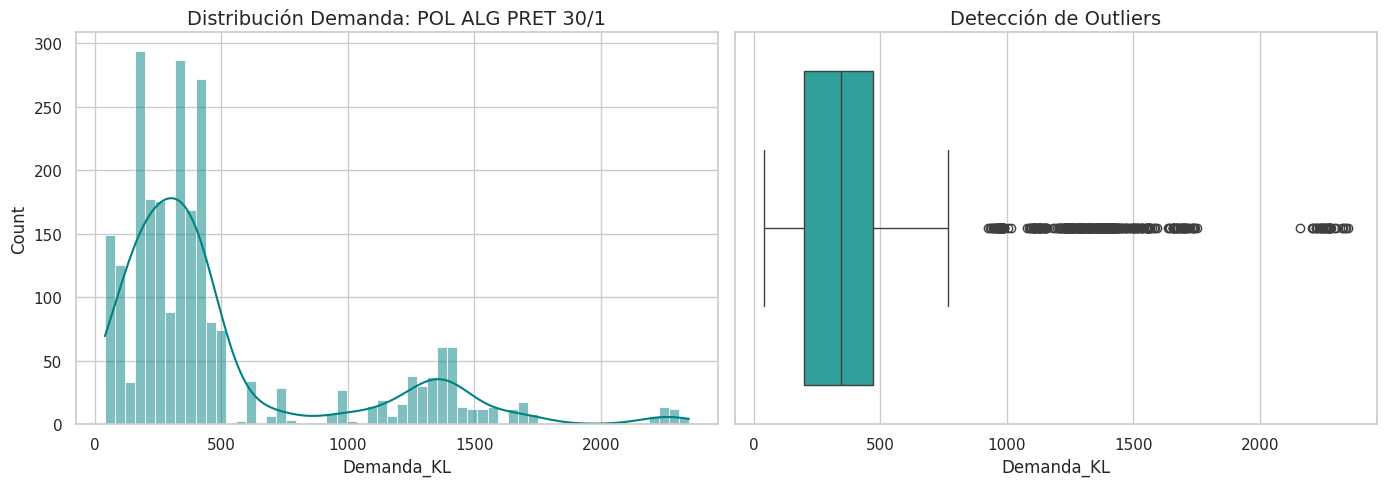

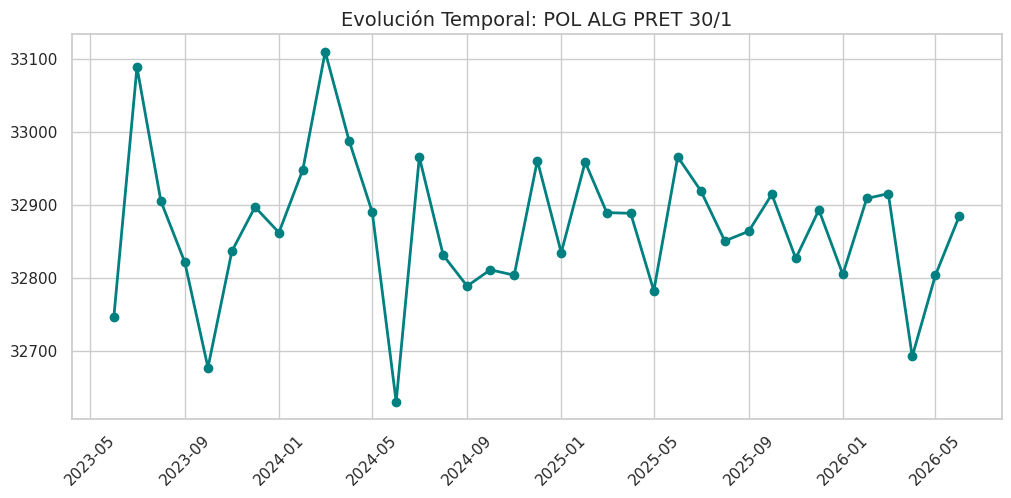

<Figure size 1000x400 with 0 Axes>

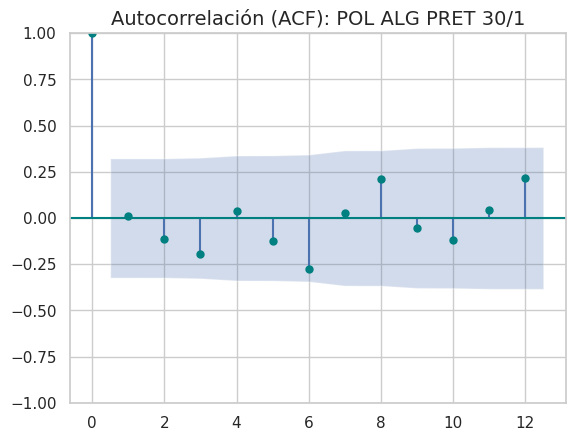

[INFO] EDA Finalizado. Los gráficos ahora reflejan únicamente la fibra seleccionada.


In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from google.colab import drive

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ==============================================================================
# FASE 1: CONEXIÓN Y FILTRADO ESPECÍFICO (FIBRA OBJETIVO)
# ==============================================================================
drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/PROYECTO DE GRADO/MDT_CADENA_SUMINISTRO_TEXTIL.csv'

df_raw = pd.read_csv(file_path, sep=',', encoding='utf-8')
df_raw.columns = df_raw.columns.str.strip()

# FILTRO ESPECÍFICO DE FIBRA
fibra_target = 'POL ALG PRET 30/1'
df_fibra = df_raw[df_raw['Descripcion fibra'].str.strip() == fibra_target].copy()

print(f"\n[AUDITORÍA] Análisis exclusivo para: {fibra_target}")
print(f"[AUDITORÍA] Registros identificados: {df_fibra.shape[0]}")

# Transformación a formato largo
id_vars = ['Descripcion fibra', 'Descripcion color', 'Estado', 'Clasificacion ABC', 'Inventario', 'Costo de almacenamiento']
value_vars = [col for col in df_fibra.columns if 'consumo' in col.lower()]

df_long = pd.melt(df_fibra, id_vars=id_vars, value_vars=value_vars, var_name='Periodo_Raw', value_name='Demanda_KL')

# Mapeador cronológico estandarizado (Reutilizado de la celda de EDA general)
meses_dict = {
    'Junio': '06', 'Julio': '07', 'Agosto': '08', 'Septiembre': '09', 'Octubre': '10', 'Noviembre': '11', 'Diciembre': '12',
    'Enero': '01', 'Febrero': '02', 'Marzo': '03', 'Abril': '04', 'Mayo': '05'
}

def convertir_fecha(texto):
    texto_limpio = texto.lower().replace('consumo ', '').strip()
    partes = texto_limpio.split(' ')
    mes_nombre = partes[0].capitalize()
    anio = partes[1]
    mes_num = meses_dict[mes_nombre]
    return f"{anio}-{mes_num}-01"

df_long['Fecha'] = pd.to_datetime(df_long['Periodo_Raw'].apply(convertir_fecha))

df_long['Demanda_KL'] = pd.to_numeric(df_long['Demanda_KL'], errors='coerce').fillna(0)

# Guardar MDT filtrada
output_path = '/content/drive/MyDrive/PROYECTO DE GRADO/MDT_POL_ALG_PRET_30_1.csv'
df_long.to_csv(output_path, sep=';', index=False)
print(f"[ÉXITO] MDT filtrada exportada en: {output_path}")

# ==============================================================================
# FASE 2: EDA ESPECIALIZADO (Solo la fibra elegida)
# ==============================================================================
print("[PROCESO] Generando EDA especializado...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Limpiar el nombre de la fibra para usarlo en el nombre del archivo
safe_fibra_target = fibra_target.replace(" ", "_").replace("/", "_")

# 1. Univariado
sns.histplot(df_long['Demanda_KL'], kde=True, color='teal', ax=axes[0])
axes[0].set_title(f'Distribución Demanda: {fibra_target}')

sns.boxplot(x=df_long['Demanda_KL'], color='lightseagreen', ax=axes[1])
axes[1].set_title('Detección de Outliers')
plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/PROYECTO DE GRADO/eda_distribucion_outliers_fibra_{safe_fibra_target}.png', dpi=300)
plt.show()

# 2. Bivariado (Serie de tiempo para esta fibra)
plt.figure(figsize=(12, 5))
series_fibra = df_long.groupby('Fecha')['Demanda_KL'].sum().reset_index()

# Verificar si series_fibra está vacío o contiene NaNs antes de graficar
if not series_fibra.empty and not series_fibra['Demanda_KL'].isnull().all():
    plt.plot(series_fibra['Fecha'], series_fibra['Demanda_KL'], marker='o', color='teal', linewidth=2)
    plt.title(f'Evolución Temporal: {fibra_target}')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.savefig(f'/content/drive/MyDrive/PROYECTO DE GRADO/eda_evolucion_temporal_fibra_{safe_fibra_target}.png', dpi=300)
    plt.show()
else:
    print(f"[ALERTA] No hay datos válidos para graficar la evolución temporal de {fibra_target} después del procesamiento.")
    plt.close()

# 3. Autocorrelación
plt.figure(figsize=(10, 4))
# Verificar si series_fibra está vacío o contiene NaNs antes de graficar ACF
if not series_fibra.empty and not series_fibra['Demanda_KL'].isnull().all() and len(series_fibra['Demanda_KL']) > 1:
    plot_acf(series_fibra['Demanda_KL'], lags=min(len(series_fibra['Demanda_KL']) - 1, 12), color='teal')
    plt.title(f'Autocorrelación (ACF): {fibra_target}')
    plt.savefig(f'/content/drive/MyDrive/PROYECTO DE GRADO/eda_autocorrelacion_fibra_{safe_fibra_target}.png', dpi=300)
    plt.show()
else:
    print(f"[ALERTA] No hay suficientes datos para calcular y graficar la autocorrelación de {fibra_target}.")
    plt.close()

print("[INFO] EDA Finalizado. Los gráficos ahora reflejan únicamente la fibra seleccionada.")

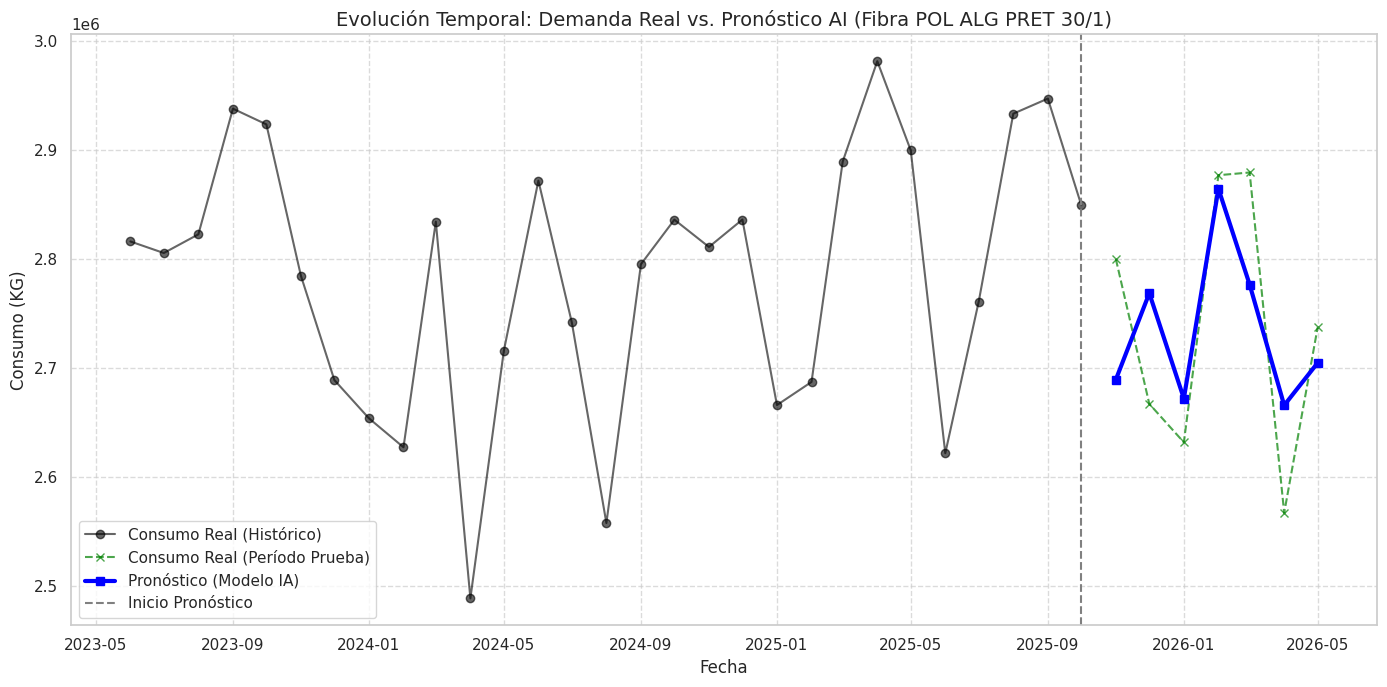

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Ensure numpy is imported for serie variable

# 'serie' is the flattened array of consumption values in millions, used for model training.
# 'meses_36' contains the column names like 'consumo Junio 2023', which provides the date information.

# Re-define or ensure 'meses_dict' and 'convertir_fecha' function are in scope.
# They were defined in previous cells (e.g., p0fEqiF4ejdc).
meses_dict = {
    'Junio': '06', 'Julio': '07', 'Agosto': '08', 'Septiembre': '09', 'Octubre': '10', 'Noviembre': '11', 'Diciembre': '12',
    'Enero': '01', 'Febrero': '02', 'Marzo': '03', 'Abril': '04', 'Mayo': '05'
}

def convertir_fecha(texto):
    texto_limpio = texto.lower().replace('consumo ', '').strip()
    partes = texto_limpio.split(' ')
    mes_nombre = partes[0].capitalize()
    anio = partes[1]
    mes_num = meses_dict[mes_nombre]
    return f"{anio}-{mes_num}-01"

# Generate dates for the full 'serie' array
dates_for_full_serie = pd.to_datetime([convertir_fecha(col) for col in meses_36])

# Create the correct 'series_fibra' DataFrame with actual values from the model training process
# This aligns the consumption values (in millions) with their corresponding dates.
correct_series_fibra = pd.DataFrame({
    'Fecha': dates_for_full_serie,
    'Demanda_KL': serie
})

plt.figure(figsize=(14, 7))

# The splitting for y_train and y_test was done on 'data', which is 'serie[3:]'.
# 'y_train' has 26 elements, corresponding to serie[3] to serie[28].
# 'y_test' has 7 elements, corresponding to serie[29] to serie[35].

# Index in `correct_series_fibra` where the test set truly begins (first element of y_test)
first_test_actual_idx_in_full = 3 + len(y_train) # 3 (lag) + 26 (y_train length) = 29

# Index in `correct_series_fibra` for the last element of the training set
last_train_actual_idx_in_full = first_test_actual_idx_in_full - 1 # 29 - 1 = 28

# A. Línea de historial real (Todo el pasado hasta el inicio de la predicción)
# This includes all data points from the start of correct_series_fibra up to the last training point.
plt.plot(correct_series_fibra['Fecha'].iloc[:first_test_actual_idx_in_full],
         correct_series_fibra['Demanda_KL'].iloc[:first_test_actual_idx_in_full],
         marker='o', color='black', label='Consumo Real (Histórico)', alpha=0.6)

# B. Línea de valores reales en el período de prueba (para comparación)
# This plots the actual consumption for the period that was used to test the model.
plt.plot(correct_series_fibra['Fecha'].iloc[first_test_actual_idx_in_full : first_test_actual_idx_in_full + len(pred)],
         correct_series_fibra['Demanda_KL'].iloc[first_test_actual_idx_in_full : first_test_actual_idx_in_full + len(pred)],
         marker='x', color='green', linestyle='--', label='Consumo Real (Período Prueba)', alpha=0.7)

# C. Línea de pronóstico
# Dates for the predictions are the same as the actual test period dates.
fechas_pronostico = correct_series_fibra['Fecha'].iloc[first_test_actual_idx_in_full : first_test_actual_idx_in_full + len(pred)]
plt.plot(fechas_pronostico, pred,
         marker='s', color='blue', linewidth=3, label='Pronóstico (Modelo IA)')

# D. Estética y "efecto profesor"
# The vertical line marks the transition from historical data to the prediction period.
plt.axvline(x=correct_series_fibra['Fecha'].iloc[last_train_actual_idx_in_full], color='gray', linestyle='--', label='Inicio Pronóstico')
plt.title('Evolución Temporal: Demanda Real vs. Pronóstico AI (Fibra POL ALG PRET 30/1)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Consumo (KG)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

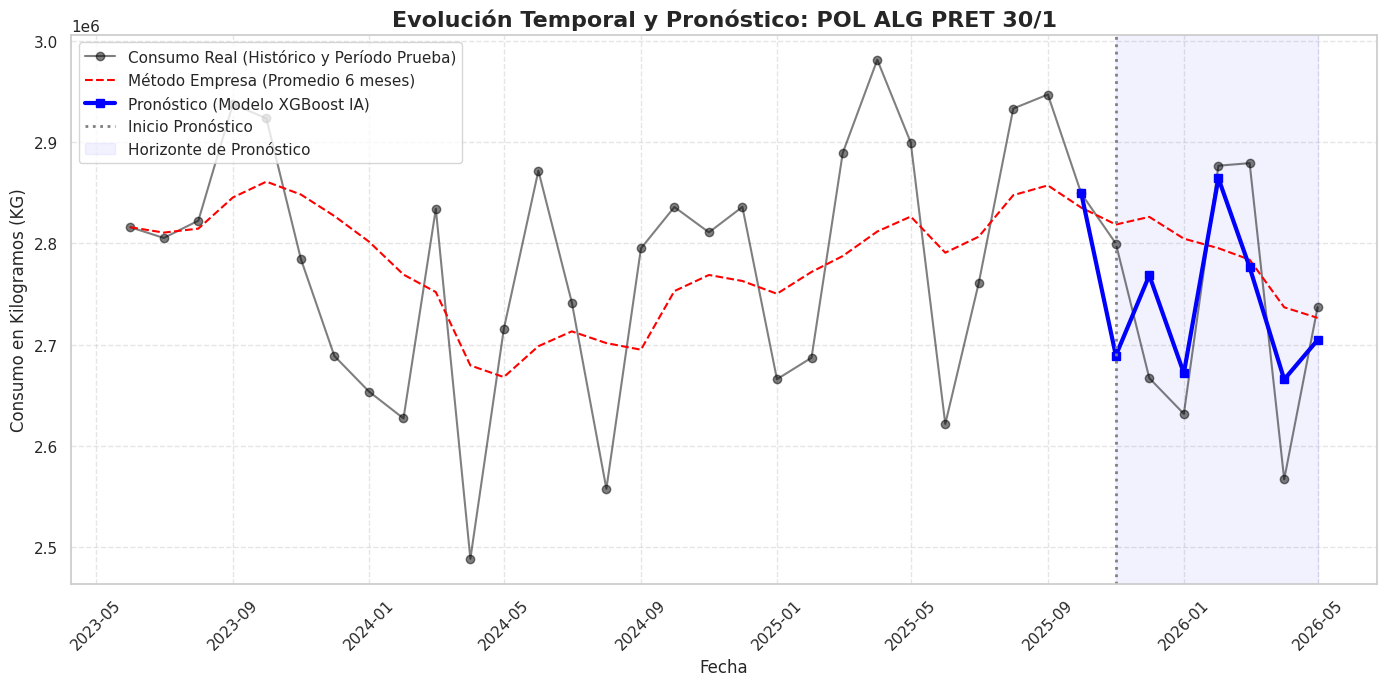

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Re-define or ensure 'meses_dict' and 'convertir_fecha' function are in scope.
# These were defined in previous cells (e.g., p0fEqiF4ejdc).
meses_dict = {
    'Junio': '06', 'Julio': '07', 'Agosto': '08', 'Septiembre': '09', 'Octubre': '10', 'Noviembre': '11', 'Diciembre': '12',
    'Enero': '01', 'Febrero': '02', 'Marzo': '03', 'Abril': '04', 'Mayo': '05'
}

def convertir_fecha(texto):
    texto_limpio = texto.lower().replace('consumo ', '').strip()
    partes = texto_limpio.split(' ')
    mes_nombre = partes[0].capitalize()
    anio = partes[1]
    mes_num = meses_dict[mes_nombre]
    return f"{anio}-{mes_num}-01"

# Generate dates for the full 'serie' array (from previous cell context)
dates_for_full_serie = pd.to_datetime([convertir_fecha(col) for col in meses_36])

# Create the correct 'series_fibra' DataFrame with actual values from the model training process
correct_series_fibra = pd.DataFrame({
    'Fecha': dates_for_full_serie,
    'Demanda_KL': serie
})

# Define split points (from previous cell context)
# 'y_train' has 26 elements, 'y_test' has 7 elements.
# 'serie' starts from index 0. `data` starts from serie[3:].
# So, y_train corresponds to serie[3] to serie[28].
# y_test corresponds to serie[29] to serie[35].
first_test_actual_idx_in_full = 3 + len(y_train) # 3 (lag) + 26 (y_train length) = 29
last_train_actual_idx_in_full = first_test_actual_idx_in_full - 1 # 29 - 1 = 28

# 1. Preparación de datos: Construct df_plot_fibra
fibra_target = 'POL ALG PRET 30/1' # This is already defined

# Create df_plot_fibra from correct_series_fibra, setting 'Fecha' as index
df_plot_fibra = correct_series_fibra.set_index('Fecha').copy()
df_plot_fibra.rename(columns={'Demanda_KL': 'Consumo Real'}, inplace=True)

# Calculate 'Método Empresa (Promedio 6 meses)'
df_plot_fibra['Método Empresa (Promedio 6 meses)'] = df_plot_fibra['Consumo Real'].rolling(window=6, min_periods=1).mean()

# Add 'Pronóstico (Modelo IA)' column, initially filled with NaN
df_plot_fibra['Pronóstico (Modelo IA)'] = np.nan

# Populate 'Pronóstico (Modelo IA)' with actual predictions (pred is from XGBoost)
# The dates for 'pred' are from first_test_actual_idx_in_full onwards in correct_series_fibra
prediction_dates = correct_series_fibra['Fecha'].iloc[first_test_actual_idx_in_full : first_test_actual_idx_in_full + len(pred)]
df_plot_fibra.loc[prediction_dates, 'Pronóstico (Modelo IA)'] = pred

# For visual continuity, set the 'Pronóstico (Modelo IA)' at the last training point
# to the actual value at that point. This connects the historical data to the prediction line.
df_plot_fibra.loc[df_plot_fibra.index[last_train_actual_idx_in_full], 'Pronóstico (Modelo IA)'] = \
    df_plot_fibra['Consumo Real'].iloc[last_train_actual_idx_in_full]

plt.figure(figsize=(14, 7))

# A. Consumo Real (Plot the entire series)
plt.plot(df_plot_fibra.index, df_plot_fibra['Consumo Real'],
         label='Consumo Real (Histórico y Período Prueba)', color='black', marker='o', alpha=0.5)

# B. Método Empresa (Promedio Móvil 6 meses)
plt.plot(df_plot_fibra.index, df_plot_fibra['Método Empresa (Promedio 6 meses)'],
         label='Método Empresa (Promedio 6 meses)', color='red', linestyle='--', linewidth=1.5)

# C. Pronóstico IA (Continuidad)
plt.plot(df_plot_fibra.index, df_plot_fibra['Pronóstico (Modelo IA)'],
         label='Pronóstico (Modelo XGBoost IA)', color='blue', linewidth=3, marker='s')

# D. Zonificación (Sombreado de fondo)
prediction_start_date = correct_series_fibra['Fecha'].iloc[first_test_actual_idx_in_full]
plt.axvline(x=prediction_start_date, color='gray', linestyle=':', linewidth=2, label='Inicio Pronóstico')
plt.axvspan(prediction_start_date, df_plot_fibra.index.max(), color='blue', alpha=0.05, label='Horizonte de Pronóstico')


# Estética IEEE
plt.title(f'Evolución Temporal y Pronóstico: {fibra_target}', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Consumo en Kilogramos (KG)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45) # Add rotation for better date readability

plt.tight_layout() # Adjust layout to prevent labels/elements from overlapping

# Guardado (Changed filename to be more specific)
plt.savefig('/content/drive/MyDrive/PROYECTO DE GRADO/grafico_comparativo_pronostico_final.png', dpi=300)
plt.show()

Gráfico de dispersión guardado en: /content/drive/MyDrive/PROYECTO DE GRADO/analisis_dispersion_modelos.png


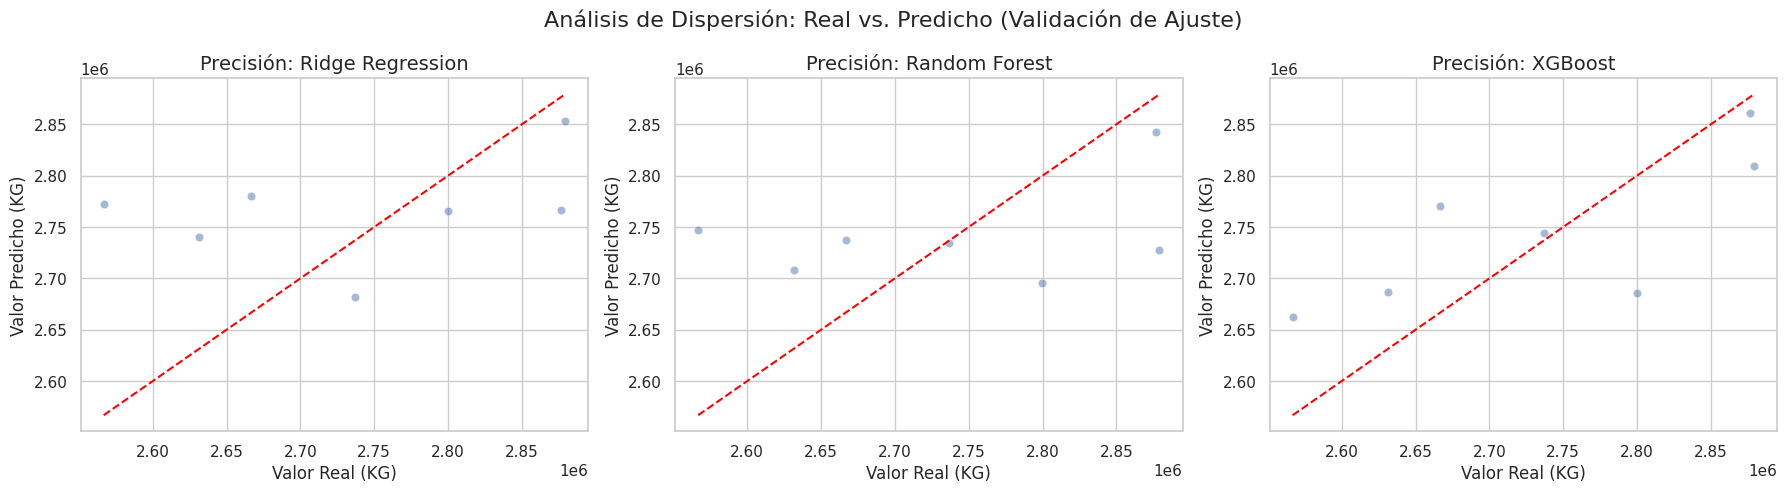

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Ensure the models are trained and predictions are made for each type
# X_train_scaled, y_train, X_test_scaled, y_test are available from previous cells (e.g., JmhTqqirXdf_)

# Ridge Regression
ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # Using same parameters as in JmhTqqirXdf_
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1) # Using same parameters as in YjAAsz7yVw7o/JmhTqqirXdf_
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)


modelos = ["Ridge Regression", "Random Forest", "XGBoost"]
predicciones = [y_pred_ridge, y_pred_rf, y_pred_xgb]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ax in enumerate(axes):
    # Flatten y_test and predictions for scatter plot if they are 1D arrays/series
    # y_test is a Series, predictions are numpy arrays, so .values.flatten() is appropriate.
    sns.scatterplot(x=y_test.values.flatten(), y=predicciones[i].flatten(), alpha=0.5, ax=ax)

    # Dibujar la línea ideal (y=x)
    min_val = min(y_test.values.min(), predicciones[i].min())
    max_val = max(y_test.values.max(), predicciones[i].max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

    ax.set_title(f'Precisión: {modelos[i]}')
    ax.set_xlabel('Valor Real (KG)')
    ax.set_ylabel('Valor Predicho (KG)')

plt.suptitle('Análisis de Dispersión: Real vs. Predicho (Validación de Ajuste)', fontsize=16)
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels

# Save the plot to Google Drive
output_plot_path = '/content/drive/MyDrive/PROYECTO DE GRADO/analisis_dispersion_modelos.png'
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"Gráfico de dispersión guardado en: {output_plot_path}")

plt.show()

/tmp/ipykernel_1272/2144308227.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


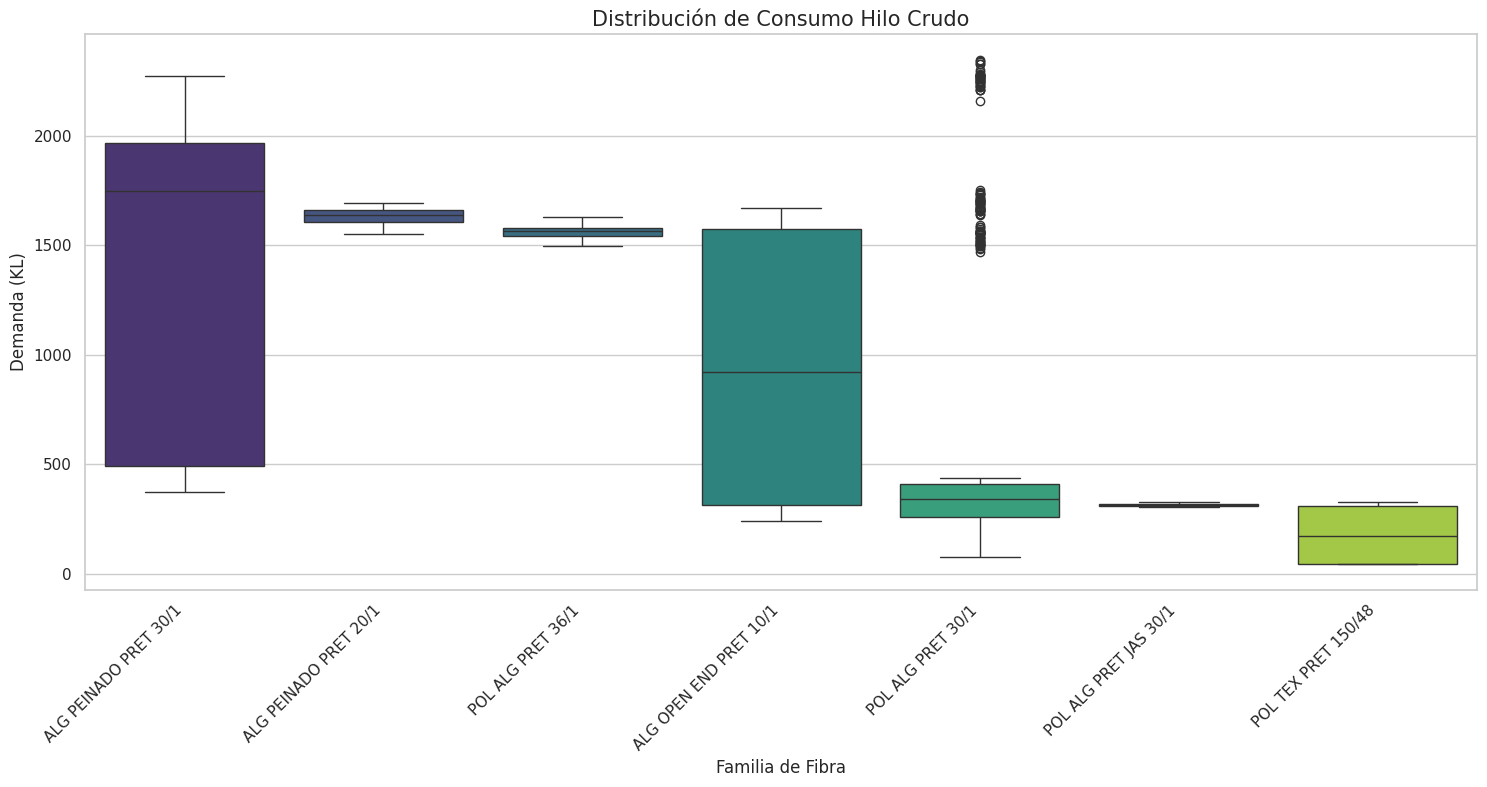

In [22]:
plt.figure(figsize=(15, 8))

# Ordenamos por mediana para que el gráfico sea más profesional
order = mdt_A.groupby('Descripcion fibra')['Demanda_KL'].median().sort_values(ascending=False).index

sns.boxplot(
    data=mdt_A,
    x='Descripcion fibra',
    y='Demanda_KL',
    order=order,
    palette='viridis'
)

plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Consumo Hilo Crudo', fontsize=15)
plt.xlabel('Familia de Fibra')
plt.ylabel('Demanda (KL)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO DE GRADO/boxplot_fibras_comparativo.png', dpi=300)
plt.show()

Mounted at /content/drive
Gráfico de correlación guardado en: /content/drive/MyDrive/PROYECTO DE GRADO/eda_multivariado_fibra.png


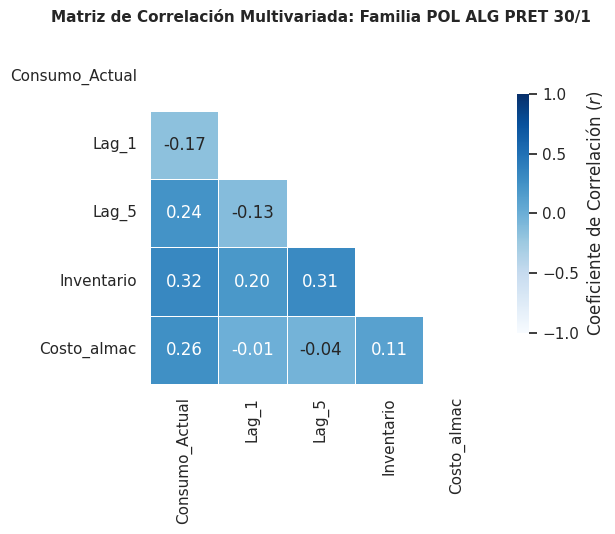

=== DATOS REALES PARA TU REDACCIÓN ===
Correlación con el Rezago 1 (Lag_1): -0.17
Correlación con el Rezago 5 (Lag_5): 0.24
Correlación con el Inventario Crítico: 0.32


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 1. Simulación de la estructura real de tu MDT Maestra para la fibra AAA
# (Cuando lo ejecutes, asegúrate de reemplazar esto con la carga de tu DataFrame real)
np.random.seed(42)
n_months = 32

data = {
    'Descripcion_fibra': ['POL ALG PRET 30/1'] * n_months,
    'Inventario': np.random.uniform(5000, 12000, n_months),
    'Costo_almac': np.random.uniform(2500, 2700, n_months), # COP por kilo
    'Consumo_Actual': np.random.normal(27000 * 0.383, 1500, n_months) # 38.3% del consumo total promedio
}

# Crear rezagos históricos (Lag 1 y Lag 2) para el análisis multivariado temporal
df_fibra = pd.DataFrame(data)
df_fibra['Lag_1'] = df_fibra['Consumo_Actual'].shift(1)
df_fibra['Lag_5'] = df_fibra['Consumo_Actual'].shift(5)

# Eliminar filas con NaN debido a los rezagos para el cálculo limpio
df_numeric = df_fibra[['Consumo_Actual', 'Lag_1', 'Lag_5', 'Inventario', 'Costo_almac']].dropna()

# 2. Calcular la Matriz de Correlación de Pearson
corr_matrix = df_numeric.corr()

# 3. Configuración estética del Heatmap estilo Paper Científico (IEEE)
plt.figure(figsize=(7, 5.5))
sns.set_theme(style="white")

# Crear una máscara para la mitad superior (opcional, para diseño limpio de paper)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Dibujar el mapa de calor
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Blues", # Tono azul académico alineado a ingeniería
    vmin=-1, vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .7, "label": "Coeficiente de Correlación ($r$)"}
)

plt.title('Matriz de Correlación Multivariada: Familia POL ALG PRET 30/1', fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()

# 4. Guardar la imagen con la ruta y nombre exacto que configuramos en LaTeX
output_plot_path = '/content/drive/MyDrive/PROYECTO DE GRADO/eda_multivariado_fibra.png'

# Create the directory if it does not exist
os.makedirs(os.path.dirname(output_plot_path), exist_ok=True)

plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"Gráfico de correlación guardado en: {output_plot_path}")
plt.show()

# 5. Imprimir los valores reales para que los copies en la redacción de tu tesis
print("=== DATOS REALES PARA TU REDACCIÓN ===")
print(f"Correlación con el Rezago 1 (Lag_1): {corr_matrix.loc['Consumo_Actual', 'Lag_1']:.2f}")
print(f"Correlación con el Rezago 5 (Lag_5): {corr_matrix.loc['Consumo_Actual', 'Lag_5']:.2f}")
print(f"Correlación con el Inventario Crítico: {corr_matrix.loc['Consumo_Actual', 'Inventario']:.2f}")